### California Housing Dataset

 Task: Predict median house prices based on features like latitude, longitude, number of rooms, population, etc.
 Traditional ML: Linear Regression, Random Forest Regressor.
 Deep Learning: Simple feedforward neural network (2–3 layers).
 Observation: Neural networks tend to outperform linear regression when non-linear relationships exist, especially with larger data.

Dataset Source: `sklearn.datasets.fetch_california_housing()`.

**Load Dataset**

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing=fetch_california_housing()

X=pd.DataFrame(housing.data,columns=housing.feature_names)
y=housing.target

**Split Dataset**

In [2]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Feature Scaling**

In [3]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

**1. Linear Regression**

In [4]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

lr.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.29,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[182.86,175.83,145. ,...,104.18, 36.96, 27.94]"


**2. Random Forest Regressor**

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

**Deep Learning Model**

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
    Dense(64,activation='relu',input_shape=(8,)),
    Dense(32,activation='relu'),
    Dense(1)
])

#compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#train model
history=model.fit(
    X_train_scaled,y_train,epochs=100,batch_size=32,validation_split=0.2
)

#evaluate model
lr_pred = lr.predict(X_test_scaled)

rf_pred = rf.predict(X_test)

ann_pred = model.predict(X_test_scaled)

ModuleNotFoundError: No module named 'tensorflow'

**Model Performance**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# -----------------------------
# Predictions
# -----------------------------
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)          # Random Forest uses unscaled data
ann_pred = model.predict(X_test_scaled).flatten()

# -----------------------------
# Performance Evaluation
# -----------------------------
results = []

# Linear Regression
results.append([
    "Linear Regression",
    mean_squared_error(y_test, lr_pred),
    mean_absolute_error(y_test, lr_pred),
    r2_score(y_test, lr_pred)
])

# Random Forest
results.append([
    "Random Forest",
    mean_squared_error(y_test, rf_pred),
    mean_absolute_error(y_test, rf_pred),
    r2_score(y_test, rf_pred)
])

# Artificial Neural Network
results.append([
    "ANN",
    mean_squared_error(y_test, ann_pred),
    mean_absolute_error(y_test, ann_pred),
    r2_score(y_test, ann_pred)
])

# -----------------------------
# Display Results
# -----------------------------
performance = pd.DataFrame(
    results,
    columns=["Model", "MSE", "MAE", "R² Score"]
)

print("\nModel Performance Comparison")
print(performance)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Model Performance Comparison
               Model       MSE       MAE  R² Score
0  Linear Regression  0.538865  0.535317  0.588781
1      Random Forest  0.255368  0.327543  0.805123
2                ANN  7.577075  1.681354 -4.782222


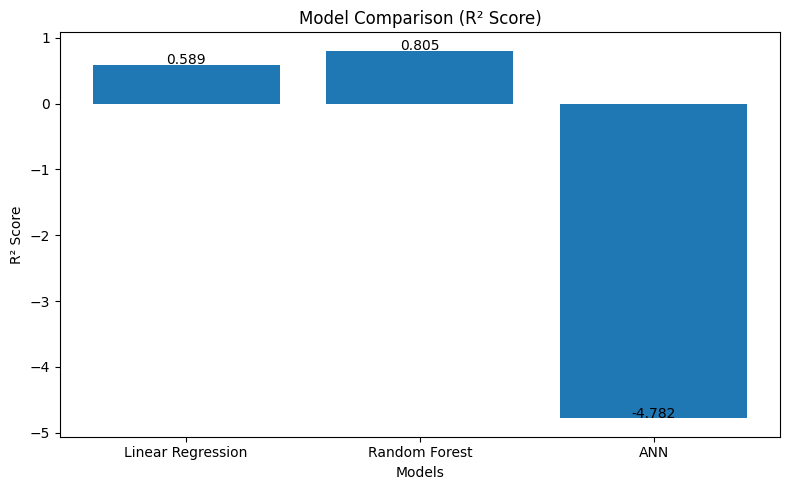

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(performance["Model"], performance["R² Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

for i, score in enumerate(performance["R² Score"]):
    plt.text(i, score + 0.01, f"{score:.3f}", ha='center')

plt.tight_layout()
plt.show()

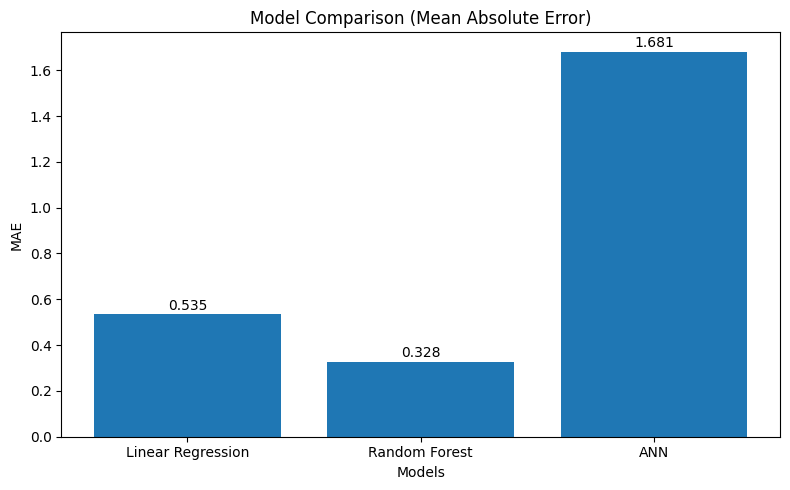

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(performance["Model"], performance["MAE"])

plt.title("Model Comparison (Mean Absolute Error)")
plt.xlabel("Models")
plt.ylabel("MAE")

for i, score in enumerate(performance["MAE"]):
    plt.text(i, score + 0.02, f"{score:.3f}", ha='center')

plt.tight_layout()
plt.show()

(b) Energy Efficiency Dataset

 Task: Predict energy load or cooling load of a building.
 Traditional ML: Ridge/Lasso Regression, SVR.
 Deep Learning: 3-layer Dense Neural Network with ReLU.
 Observation: DL captures complex non-linear patterns better.

Dataset Source: [UCI Machine Learning Repository – Energy Efficiency](https://archive.ics.uci.edu/ml/datasets/energy+efficiency).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

#tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


#set random seed
np.random.seed(42)
tf.random.set_seed(42)

#data
url="https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
data=pd.read_excel(url)


In [ ]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
#rename columns
data.columns = [
    "RelativeCompactness",
    "SurfaceArea",
    "WallArea",
    "RoofArea",
    "OverallHeight",
    "Orientation",
    "GlazingArea",
    "GlazingAreaDistribution",
    "HeatingLoad",
    "CoolingLoad"
]
data.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
#features and target
x=data.iloc[:,:-2]
y=data['HeatingLoad']
x.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [ ]:
y.head()

#to predict cooling load use y=data['CoolingLoad']

,HeatingLoad
0,15.55
1,15.55
2,15.55
3,15.55
4,20.84


In [ ]:
#train-test-split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


#feature scaling
scaler=StandardScaler()

#fit_transform() learns the mean and SD from training data and transforms x_train
x_train_scaled=scaler.fit_transform(x_train)

#transform() applies the learned mean and SD from x_train without re-learning from x_test to prevent data leakage and feature mismatch
x_test_scaled=scaler.transform(x_test)


Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 548.7712 - mae: 21.0817 - val_loss: 447.3547 - val_mae: 18.8504
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 430.7456 - mae: 18.0209 - val_loss: 294.6958 - val_mae: 14.3246
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 234.5207 - mae: 11.8371 - val_loss: 108.7728 - val_mae: 7.1851
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 74.4435 - mae: 5.9215 - val_loss: 38.7690 - val_mae: 4.2782
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35.7857 - mae: 3.9119 - val_loss: 29.8088 - val_mae: 3.6458
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 27.8654 - mae: 3.5073 - val_loss: 25.7266 - val_mae: 3.4900
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.3132 - mae: 3.4003 - val_loss: 23.7640 - val_mae: 3.4677
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.0529 - mae: 3.2845 - val_loss: 22.2576 - val_mae: 3.4027
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━

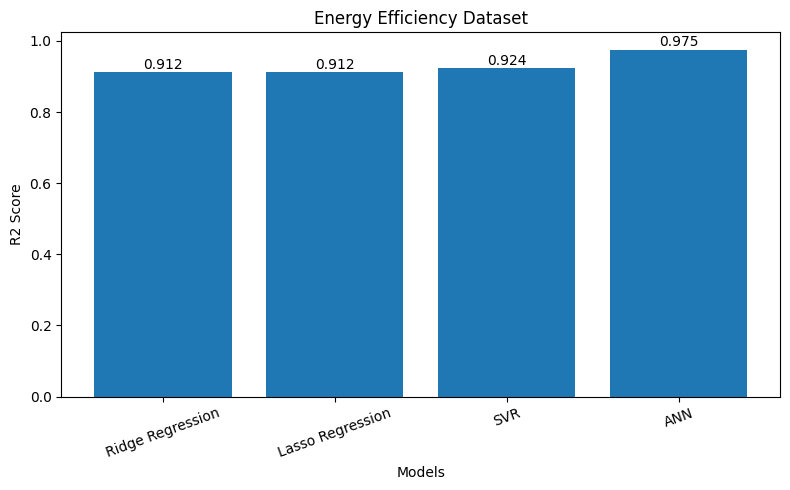

In [ ]:
#Ridge Regression
ridge=Ridge(alpha=1.0)
ridge.fit(x_train_scaled,y_train)
ridge_pred = ridge.predict(x_test_scaled)

#Lasso Regression
lasso=Lasso(alpha=0.01)
lasso.fit(x_train_scaled,y_train)
lasso_pred = lasso.predict(x_test_scaled)

#Support Vector Regression
svr=SVR(kernel='rbf')
svr.fit(x_train_scaled,y_train)
svr_pred = svr.predict(x_test_scaled)

#deep neural network
from tensorflow.keras.layers import Input
model=Sequential([
    Input(shape=(x_train_scaled.shape[1],)), # Use Input layer to define input shape
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1)
])

#compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

#train the model with the data
history=model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1 #to show a detailed progress bar and real-time training metrics
)

ann_pred=model.predict(x_test_scaled).flatten() #output converted to a 1-D numpy array to match with the evaluation metrics

#performance comparison
results=[]

models={
    'Ridge Regression':ridge_pred,
    'Lasso Regression':lasso_pred,
    'SVR':svr_pred,
    'ANN':ann_pred
}

for name,pred in models.items():
  mse=mean_squared_error(y_test,pred)
  mae=mean_absolute_error(y_test,pred)
  r2=r2_score(y_test,pred)
  results.append([name, mse, mae, r2]) # Append results inside the loop

performance=pd.DataFrame(
    results,
    columns=['Model','MSE','MAE','R2 Score']
)

print('\nPerformance Comparison')
print(performance)

#plot r2 score
plt.figure(figsize=(8,5))
plt.bar(performance['Model'],performance['R2 Score']) # Corrected from 'R² Score' to 'R2 Score'
plt.title('Energy Efficiency Dataset')
plt.xlabel('Models')
plt.ylabel('R2 Score')

for i, score in enumerate(performance['R2 Score']):
  plt.text(i,score+0.01,f'{score:.3f}',ha='center')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

(c) Bike Sharing Dataset

 Task: Predict number of bike rentals on a given day.
 Traditional ML: Gradient Boosted Regression Trees, Linear Regression.
 Deep Learning: LSTM (for time-series) or Dense Neural Network.
 Observation: Neural networks handle temporal dependencies better when using time-series variants like LSTM.

Dataset Source: [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset).

Dataset Shape: (731, 16)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

               Model           MSE          MAE  R2 Score
0  Linear Regression  1.215863e+06   803.625377  0.654014
1  Gradient Boosting  1.477698e+06  1047.255796  0.579507
2                ANN  1.659620e+06  1040.904297  0.527739
3               LSTM  4.166411e+06  1735.796906 -0.122102


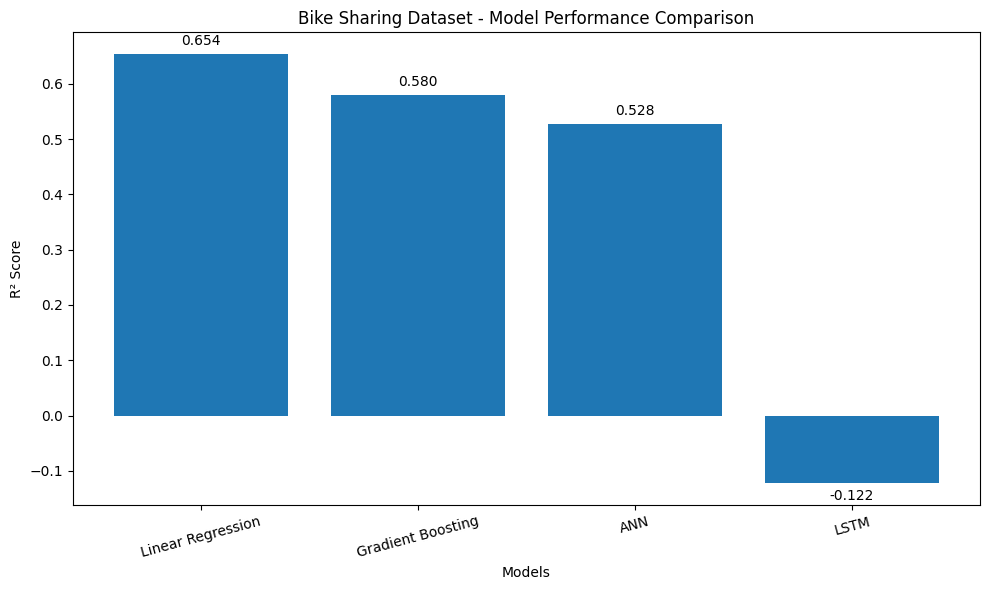

In [ ]:
import numpy as np
import pandas as pd
import requests
from zipfile import ZipFile
from io import BytesIO
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# --------------------------------------------------
# 1. Download & Read Dataset
# --------------------------------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
response = requests.get(url)

with ZipFile(BytesIO(response.content)) as z:
    data = pd.read_csv(z.open("day.csv"))

print("Dataset Shape:", data.shape)

# --------------------------------------------------
# 2. Preprocess & One-Hot Encode
# --------------------------------------------------
x_raw = data.drop(columns=["instant", "dteday", "casual", "registered", "cnt"])
y_raw = data["cnt"].values

x_processed = pd.get_dummies(
    x_raw, columns=['season', 'mnth', 'weekday', 'weathersit'], drop_first=True
)

# --------------------------------------------------
# 3. Chronological Time-Series Split (No Random Shuffle)
# --------------------------------------------------
split_idx = int(len(x_processed) * 0.8)

x_train_raw = x_processed.iloc[:split_idx]
x_test_raw = x_processed.iloc[split_idx:]

y_train_raw = y_raw[:split_idx]
y_test_raw = y_raw[split_idx:]

# --------------------------------------------------
# 4. Feature and Target Scaling (Fit ON TRAIN ONLY)
# --------------------------------------------------
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_scaled = scaler_x.fit_transform(x_train_raw)
x_test_scaled = scaler_x.transform(x_test_raw)

# Target scaling for Neural Networks
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

# --------------------------------------------------
# 5. Model 1: Linear Regression
# --------------------------------------------------
lr = LinearRegression()
lr.fit(x_train_scaled, y_train_raw)
lr_pred = lr.predict(x_test_scaled)

# --------------------------------------------------
# 6. Model 2: Gradient Boosting Regressor
# --------------------------------------------------
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(x_train_scaled, y_train_raw)
gbr_pred = gbr.predict(x_test_scaled)

# --------------------------------------------------
# 7. Model 3: Dense ANN (Trained on Scaled Target)
# --------------------------------------------------
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse')
ann_model.fit(
    x_train_scaled, y_train_scaled,
    epochs=100, batch_size=16, verbose=0
)

# Predict and inverse-transform back to original scale
ann_preds_scaled = ann_model.predict(x_test_scaled).flatten()
ann_pred = scaler_y.inverse_transform(ann_preds_scaled.reshape(-1, 1)).flatten()

# --------------------------------------------------
# 8. Model 4: LSTM (Sequenced Inputs)
# --------------------------------------------------
def create_sequences(X, y, time_steps=14):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

time_steps = 14
X_train_seq, y_train_seq = create_sequences(x_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(x_test_scaled, y_test_scaled, time_steps)

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=16, shuffle=False, verbose=0)

# Predict and inverse-transform
lstm_preds_scaled = lstm_model.predict(X_test_seq).flatten()
lstm_pred = scaler_y.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()
y_test_lstm_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# --------------------------------------------------
# 9. Performance Evaluation & Visualization
# --------------------------------------------------
results = []

# Non-LSTM evaluations against full test set
models_eval = {
    'Linear Regression': (y_test_raw, lr_pred),
    'Gradient Boosting': (y_test_raw, gbr_pred),
    'ANN': (y_test_raw, ann_pred),
    'LSTM': (y_test_lstm_actual, lstm_pred)
}

for name, (y_true, y_pred) in models_eval.items():
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results.append([name, mse, mae, r2])

performance = pd.DataFrame(results, columns=['Model', 'MSE', 'MAE', 'R2 Score'])
print("\n" + "="*50)
print(performance)
print("="*50)

# Plotting Results
plt.figure(figsize=(10, 6))
bars = plt.bar(performance['Model'], performance['R2 Score'])
plt.title('Bike Sharing Dataset - Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('R² Score')

for i, score in enumerate(performance['R2 Score']):
    va = 'bottom' if score >= 0 else 'top'
    offset = 0.01 if score >= 0 else -0.01
    plt.text(i, score + offset, f"{score:.3f}", ha='center', va=va)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --------------------------------------------------
# 1. Prepare Features and Target
# --------------------------------------------------
X_raw = data.drop(columns=["instant", "dteday", "casual", "registered", "cnt"])
y_raw = data["cnt"].values  # Convert to numpy array

X_processed = pd.get_dummies(X_raw, columns=['season','mnth','weekday','weathersit'], drop_first=True).values

# --------------------------------------------------
# 2. Time-Series Train-Test Split BEFORE Scaling
# --------------------------------------------------
split_idx = int(len(X_processed) * 0.8)

X_train_raw = X_processed[:split_idx]
X_test_raw = X_processed[split_idx:]

y_train_raw = y_raw[:split_idx]
y_test_raw = y_raw[split_idx:]

# --------------------------------------------------
# 3. Scale Features AND Target (Fit ONLY on Train)
# --------------------------------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

# Target must be 2D for StandardScaler: (N, 1)
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

# --------------------------------------------------
# 4. Create Sequences Function
# --------------------------------------------------
def create_sequences(X, y, time_steps=14):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

time_steps = 14

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)

# --------------------------------------------------
# 5. Build & Train LSTM
# --------------------------------------------------
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")

history = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=16,
    shuffle=False,  # Keep sequence order intact
    verbose=1
)

# --------------------------------------------------
# 6. Predict & Inverse Transform Target
# --------------------------------------------------
scaled_preds = model_lstm.predict(X_test_seq).flatten()

# Rescale predictions and ground-truth back to original bike count numbers
lstm_pred = scaler_y.inverse_transform(scaled_preds.reshape(-1, 1)).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# --------------------------------------------------
# 7. Evaluate
# --------------------------------------------------
mse_lstm = mean_squared_error(y_test_actual, lstm_pred)
mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
r2_lstm = r2_score(y_test_actual, lstm_pred)

print("\nFixed LSTM Performance")
print(f"MSE : {mse_lstm:.2f}")
print(f"MAE : {mae_lstm:.2f}")
print(f"R²  : {r2_lstm:.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.9198
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3157
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2433
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2131
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2048
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2297
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2243
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2946
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2437
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2595
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2045
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1928
Epoch 13/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1601
Epoch 14/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1585
Epoch 15/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1680
Epoch 16/50
36/3

(a) Binary Classification
Dataset: Breast Cancer Wisconsin (Diagnostic) Dataset
Goal: Predict whether a tumor is malignant or benign.

Features: Radius, texture, perimeter, area, smoothness, etc. (30 numeric features).

Traditional ML: Logistic Regression, Random Forest, SVM.

Deep Learning: 3-layer Dense Neural Network using Keras.


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.7418 - loss: 0.5109 - val_accuracy: 0.9780 - val_loss: 0.2891
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.2038 - val_accuracy: 0.9890 - val_loss: 0.1205
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.1028 - val_accuracy: 0.9890 - val_loss: 0.0734
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0756 - val_accuracy: 0.9890 - val_loss: 0.0562
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9863 - loss: 0.0616 - val_accuracy: 0.9890 - val_loss: 0.0462
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - loss: 0.0526 - val_accuracy: 0.9890 - val_loss: 0.0411
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.0463 - val_accuracy: 0.9890 - val_loss: 0.0362
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.0396 - val_accuracy: 0.9890 - val_loss: 0.

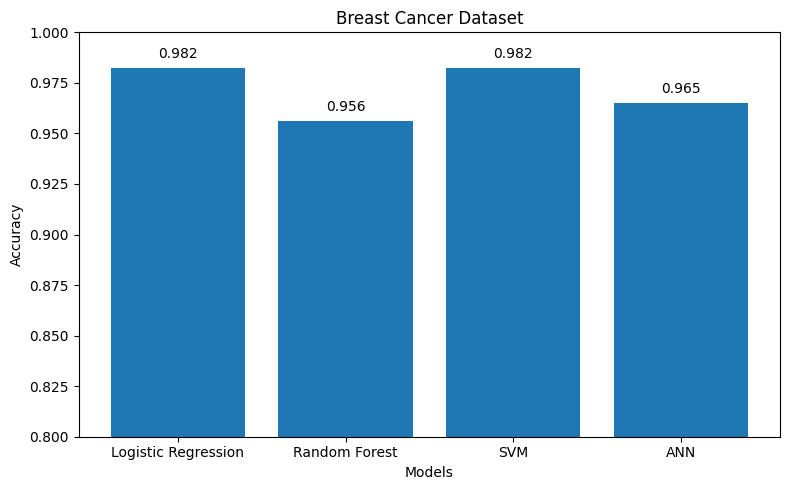

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

X, y = load_breast_cancer(return_X_y=True)

# --------------------------------------------------
# Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

# --------------------------------------------------
# Random Forest
# --------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# --------------------------------------------------
# Support Vector Machine
# --------------------------------------------------

svm = SVC()

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

# --------------------------------------------------
# Deep Neural Network
# --------------------------------------------------

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

loss, ann_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

ann_pred = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()

# --------------------------------------------------
# Model Comparison
# --------------------------------------------------

model_names = []
accuracies = []

models = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "ANN": ann_accuracy
}

print("\nModel Performance")
print("-" * 35)

for name, acc in models.items():
    model_names.append(name)
    accuracies.append(acc)
    print(f"{name:22s}: {acc:.4f}")

# --------------------------------------------------
# Accuracy Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.title("Breast Cancer Dataset")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha='center')

plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

(b) Multi-Class Classification
Dataset: Wine Classification Dataset
Goal: Predict the wine cultivar (class 0, 1, or 2) based on chemical composition.

Features: 13 numeric attributes like alcohol, malic acid, ash, flavanoids, etc.

Traditional ML: Decision Tree, K-Nearest Neighbors, Logistic Regression.

Deep Learning: 2-layer feedforward NN with softmax output.


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.5221 - loss: 1.0411 - val_accuracy: 0.4828 - val_loss: 1.0185
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7345 - loss: 0.8357 - val_accuracy: 0.7931 - val_loss: 0.8379
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9027 - loss: 0.6802 - val_accuracy: 0.8621 - val_loss: 0.6804
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9292 - loss: 0.5499 - val_accuracy: 0.9310 - val_loss: 0.5376
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9292 - loss: 0.4456 - val_accuracy: 0.9310 - val_loss: 0.4069
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9469 - loss: 0.3589 - val_accuracy: 0.9655 - val_loss: 0.3194
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9558 - loss: 0.2918 - val_accuracy: 1.0000 - val_loss: 0.2456
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9558 - loss: 0.2390 - val_accuracy: 1.0000 - val_loss: 0.1939
Epo

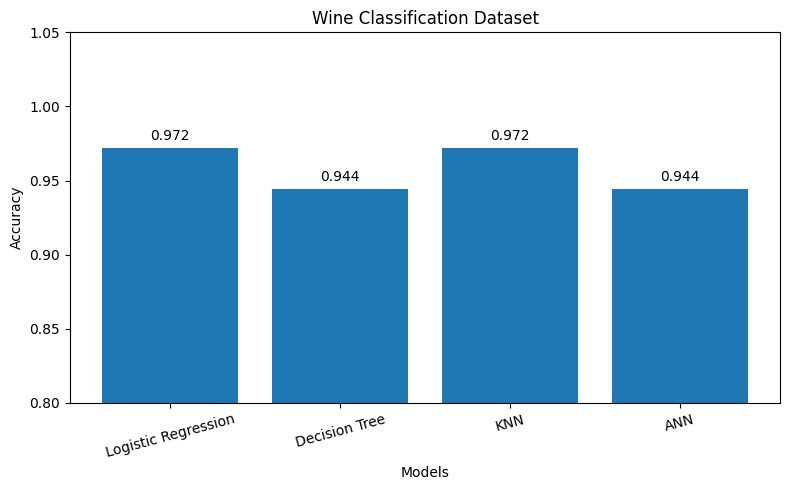

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

X, y = load_wine(return_X_y=True)

# --------------------------------------------------
# Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# Traditional ML Models
# --------------------------------------------------

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

# --------------------------------------------------
# Deep Learning Model
# --------------------------------------------------

# One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))   # 3 output classes

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

loss, ann_accuracy = model.evaluate(
    X_test_scaled,
    y_test_cat,
    verbose=0
)

# --------------------------------------------------
# Model Comparison
# --------------------------------------------------

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "KNN",
    "ANN"
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, knn_pred),
    ann_accuracy
]

print("\nModel Comparison")
print("-" * 35)

for name, acc in zip(model_names, accuracies):
    print(f"{name:22s}: {acc:.4f}")

# --------------------------------------------------
# Accuracy Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.title("Wine Classification Dataset")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha='center')

plt.ylim(0.8, 1.05)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

(c) IMDB Movie Reviews (Sentiment Analysis)

 Task: Classify reviews as positive or negative.
 Traditional ML: Bag-of-Words + Logistic Regression / Naive Bayes.
 Deep Learning: LSTM / GRU / Transformer (Word Embeddings).
 Observation: DL with pre-trained embeddings (e.g., GloVe) achieves much higher accuracy.

Dataset Source: `tf.keras.datasets.imdb`.


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7934 - loss: 0.4368 - val_accuracy: 0.8198 - val_loss: 0.4042
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8957 - loss: 0.2571 - val_accuracy: 0.8606 - val_loss: 0.3283
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9319 - loss: 0.1866 - val_accuracy: 0.8578 - val_loss: 0.3706
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9489 - loss: 0.1392 - val_accuracy: 0.8660 - val_loss: 0.3806
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9621 - loss: 0.1073 - val_accuracy: 0.8570 - val_loss: 0.4052
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

Model Comparison
-----------------------------------
Logistic Regression   : 0.8555
Naive Bayes           : 0.8184
LSTM                  : 0.8548


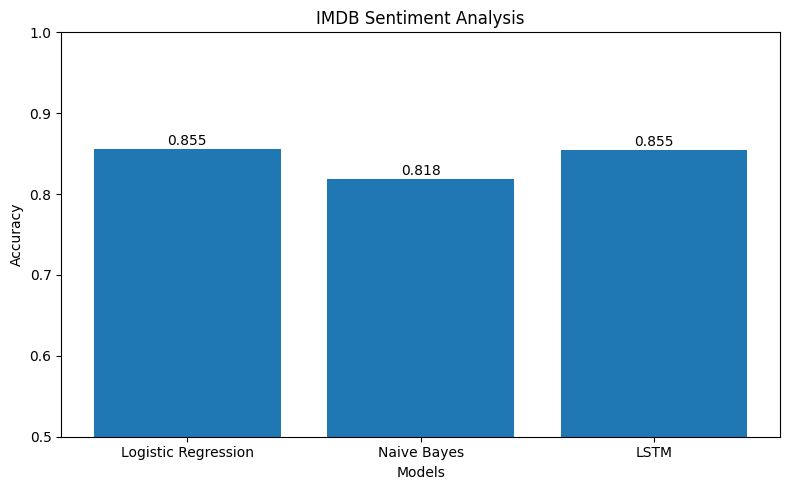

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

num_words = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

# --------------------------------------------------
# Convert Integer Sequences Back to Text
# --------------------------------------------------

word_index = imdb.get_word_index()

reverse_word_index = {
    value + 3: key for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(i, "?")
        for i in sequence
    )

X_train_text = [decode_review(review) for review in X_train]
X_test_text = [decode_review(review) for review in X_test]

# --------------------------------------------------
# Bag-of-Words
# --------------------------------------------------

vectorizer = CountVectorizer(max_features=10000)

X_train_bow = vectorizer.fit_transform(X_train_text)
X_test_bow = vectorizer.transform(X_test_text)

# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_bow, y_train)

lr_pred = lr.predict(X_test_bow)

# --------------------------------------------------
# Naive Bayes
# --------------------------------------------------

nb = MultinomialNB()

nb.fit(X_train_bow, y_train)

nb_pred = nb.predict(X_test_bow)

# --------------------------------------------------
# Prepare Data for LSTM
# --------------------------------------------------

max_length = 200

X_train_pad = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test,
    maxlen=max_length
)

# --------------------------------------------------
# LSTM Model
# --------------------------------------------------

model = Sequential()

model.add(
    Embedding(
        input_dim=num_words,
        output_dim=128,
        input_length=max_length
    )
)

model.add(LSTM(64))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

loss, lstm_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

lstm_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()

# --------------------------------------------------
# Performance Comparison
# --------------------------------------------------

model_names = [
    "Logistic Regression",
    "Naive Bayes",
    "LSTM"
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, nb_pred),
    lstm_accuracy
]

print("\nModel Comparison")
print("-" * 35)

for name, acc in zip(model_names, accuracies):
    print(f"{name:22s}: {acc:.4f}")

# --------------------------------------------------
# Accuracy Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.title("IMDB Sentiment Analysis")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha="center")

plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

(d) Titanic Survival Dataset

 Task: Predict survival of passengers.
 Traditional ML: Logistic Regression, Random Forest.
 Deep Learning: Dense Neural Network (3 hidden layers).
 Observation: Random Forest and Gradient Boosting often perform better due to small dataset size, but DL matches after feature scaling.

/tmp/ipykernel_1458/3628364905.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)
/tmp/ipykernel_1458/3628364905.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7592 - loss: 0.5626 - val_accuracy: 0.7762 - val_loss: 0.4945
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7979 - loss: 0.4443 - val_accuracy: 0.7832 - val_loss: 0.4648
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8278 - loss: 0.4076 - val_accuracy: 0.7972 - val_loss: 0.4731
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8383 - loss: 0.3898 - val_accuracy: 0.8182 - val_loss: 0.4690
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8348 - loss: 0.3894 - val_accuracy: 0.8042 - val_loss: 0.4689
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8489 - loss: 0.3736 - val_accuracy: 0.7972 - val_loss: 0.4818
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 0.3683 - val_accuracy: 0.7692 - val_loss: 0.5051
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8541 - loss: 0.3653 - val_accuracy: 0.8112 - val_loss: 0.

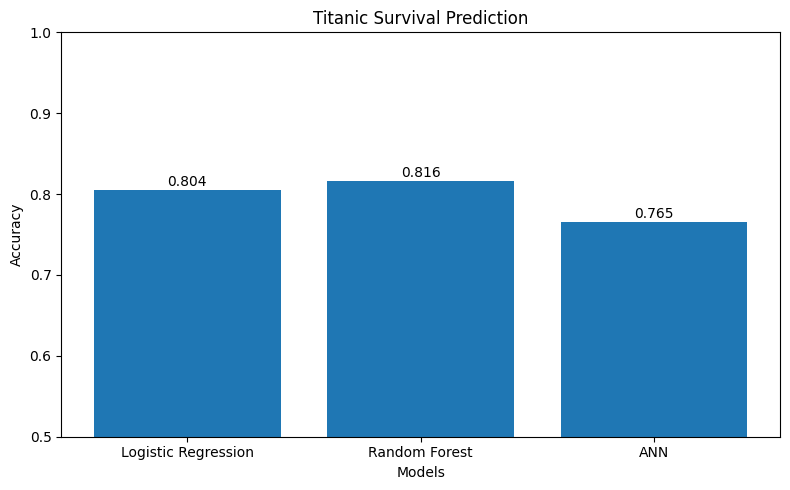

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

data = pd.read_csv(url)

# --------------------------------------------------
# Data Preprocessing
# --------------------------------------------------

# Drop unnecessary columns
data.drop(
    ["PassengerId", "Name", "Ticket", "Cabin"],
    axis=1,
    inplace=True
)

# Fill missing values
data["Age"].fillna(data["Age"].median(), inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

# Convert categorical variables
data = pd.get_dummies(
    data,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Features and Target
X = data.drop("Survived", axis=1)
y = data["Survived"]

# --------------------------------------------------
# Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

# --------------------------------------------------
# Random Forest
# --------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# --------------------------------------------------
# Deep Neural Network
# --------------------------------------------------

model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

loss, ann_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

ann_pred = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()

# --------------------------------------------------
# Performance Comparison
# --------------------------------------------------

model_names = [
    "Logistic Regression",
    "Random Forest",
    "ANN"
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    ann_accuracy
]

print("\nModel Comparison")
print("-" * 35)

for name, acc in zip(model_names, accuracies):
    print(f"{name:22s}: {acc:.4f}")

# --------------------------------------------------
# Accuracy Plot
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.title("Titanic Survival Prediction")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha="center")

plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()